In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# --- 1. Wireless Environment Parameters ---
B_HZ = 1e6              # 1 MHz
N0_DBM_HZ = -174        # Noise density
P_TX_CLIENT_DBM = 24    # Uplink Power
P_TX_SERVER_DBM = 46    # Downlink Power (Server)
Q_BITS = 16             # 16-bit quantization
RADIUS_KM = 0.5         # 500m
DEVICE_GFLOPS = 2.0     # Average edge device speed (2 Billion operations/sec)

In [19]:
# --- 2. Model Architectures ---

class SVMModel(nn.Module):
    def __init__(self):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(3072, 1)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, 10))
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

In [34]:
# --- 3. Wireless Channel ---

def get_round_delays(model, task):
    # --- Wireless Communication Delay ---
    noise_w = 10**(((N0_DBM_HZ + 10 * np.log10(B_HZ)) - 30) / 10)
    r_km = RADIUS_KM * np.sqrt(np.random.rand(30)) 
    path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
    
    def get_max_delay(p_tx_dbm):
        p_rx_w = 10**(((p_tx_dbm - path_loss_db) - 30) / 10)
        rates = B_HZ * np.log2(1 + (p_rx_w / noise_w))
        num_params = sum(p.numel() for p in model.parameters())
        return np.max((num_params * Q_BITS) / rates)

    d_down = get_max_delay(P_TX_SERVER_DBM)
    d_up = get_max_delay(P_TX_CLIENT_DBM)

    # --- Computation Delay ---
    # SVM: ~3k FLOPs per image | CNN: ~15M FLOPs per image (forward + backward)
    flops_per_img = 6000 if task == 'SVM' else 15_000_000
    num_samples = 330 if task == 'SVM' else 2000
    t_comp = (num_samples * flops_per_img) / (DEVICE_GFLOPS * 1e9)

    return d_down, t_comp, d_up

In [35]:
# --- 4. Data Preparation ---

def get_datasets(task='CNN'):
    if task == 'SVM':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        
        # Filter classes 0 (airplane) and 1 (automobile)
        train_idx = [i for i, l in enumerate(train_set.targets) if l in [0, 1]]
        test_idx = [i for i, l in enumerate(test_set.targets) if l in [0, 1]]
        
        # 15 devices get only airplanes, 15 get only automobiles (330 samples each)
        airplanes = [i for i in train_idx if train_set.targets[i] == 0][:15*330]
        autos = [i for i in train_idx if train_set.targets[i] == 1][:15*330]
        
        device_data = [Subset(train_set, airplanes[i*330:(i+1)*330]) for i in range(15)] + \
                      [Subset(train_set, autos[i*330:(i+1)*330]) for i in range(15)]
        
        return device_data, Subset(test_set, test_idx), SVMModel(), 0.0001

    else: # CNN Task
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        
        # Pathological Non-IID: Sort by label, 60 shards, 2 per client
        indices = np.argsort(train_set.targets.numpy())
        shards = [indices[i*1000 : (i+1)*1000] for i in range(60)]
        device_data = [Subset(train_set, np.concatenate((shards[i*2], shards[i*2+1]))) for i in range(30)]
        
        return device_data, test_set, CNNModel(), 0.005

In [ ]:
# --- 4. Main Training Logic ---

def run_full_wireless_fl(task='CNN', rounds=15):
    device_data, test_set, global_model, lr = get_datasets(task)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)
    criterion = nn.MSELoss() if task == 'SVM' else nn.CrossEntropyLoss()
    
    history = {'acc': [], 'time': []}
    cumulative_time = 0

    print(f"\n--- Simulation: {task} | 30 Clients | {rounds} Rounds ---")

    for r in range(rounds):
        # Calculate Simulated Time for this round
        d_down, t_comp, d_up = get_round_delays(global_model, task)
        round_simulated_time = d_down + t_comp + d_up
        cumulative_time += round_simulated_time
        
        local_weights = []
        # Local Training (The "Wait" time for your laptop)
        for i in range(30):
            local_model = type(global_model)()
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.SGD(local_model.parameters(), lr=lr)
            loader = DataLoader(device_data[i], batch_size=32, shuffle=True)
            
            local_model.train()
            for data, target in loader:
                if task == 'SVM': target = (target.float() * 2) - 1
                optimizer.zero_grad()
                loss = criterion(local_model(data).squeeze(), target)
                loss.backward()
                optimizer.step()
            local_weights.append(local_model.state_dict())
        
        # Aggregation (FedAvg)
        avg_weights = {}
        for key in local_weights[0].keys():
            avg_weights[key] = torch.stack([local_weights[j][key] for j in range(30)], 0).mean(0)
        global_model.load_state_dict(avg_weights)
        
        # Evaluation
        global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = global_model(data)
                if task == 'SVM':
                    correct += (torch.sign(output.squeeze()) == (target.float()*2-1)).sum().item()
                else:
                    correct += (output.argmax(1) == target).sum().item()
                total += target.size(0)
        
        acc = 100. * correct / total
        history['acc'].append(acc)
        history['time'].append(cumulative_time)
        
        print(f"Round {r+1:02d} | Acc: {acc:.2f}% | Sim Time: {cumulative_time:.2f}s (Round: {round_simulated_time:.4f}s)")

    # --- Plotting ---
    plt.figure(figsize=(10, 5))
    plt.plot(history['time'], history['acc'], 'b-o', markersize=4)
    plt.title(f'Accuracy vs. Training Time ({task})')
    plt.xlabel('Training Time (Seconds)')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True, alpha=0.3)
    plt.show()


--- Simulation: SVM | 30 Clients | 200 Rounds ---
Round 01 | Acc: 67.00% | Sim Time: 0.01s (Round: 0.0113s)
Round 02 | Acc: 69.20% | Sim Time: 0.02s (Round: 0.0114s)
Round 03 | Acc: 70.05% | Sim Time: 0.03s (Round: 0.0113s)
Round 04 | Acc: 71.35% | Sim Time: 0.05s (Round: 0.0114s)
Round 05 | Acc: 72.30% | Sim Time: 0.06s (Round: 0.0114s)
Round 06 | Acc: 73.05% | Sim Time: 0.07s (Round: 0.0112s)
Round 07 | Acc: 73.75% | Sim Time: 0.08s (Round: 0.0113s)
Round 08 | Acc: 74.40% | Sim Time: 0.09s (Round: 0.0112s)
Round 09 | Acc: 74.75% | Sim Time: 0.10s (Round: 0.0114s)
Round 10 | Acc: 75.35% | Sim Time: 0.11s (Round: 0.0111s)
Round 11 | Acc: 75.95% | Sim Time: 0.12s (Round: 0.0114s)
Round 12 | Acc: 76.25% | Sim Time: 0.14s (Round: 0.0114s)
Round 13 | Acc: 76.70% | Sim Time: 0.15s (Round: 0.0109s)
Round 14 | Acc: 76.65% | Sim Time: 0.16s (Round: 0.0113s)
Round 15 | Acc: 76.80% | Sim Time: 0.17s (Round: 0.0114s)
Round 16 | Acc: 76.85% | Sim Time: 0.18s (Round: 0.0113s)
Round 17 | Acc: 77.15

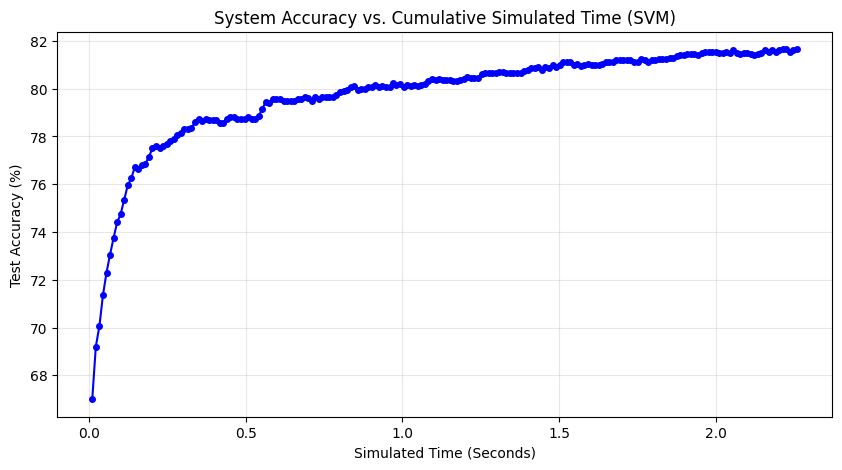

In [39]:
run_full_wireless_fl(task='SVM', rounds=200)


--- Simulation: CNN | 30 Clients | 200 Rounds ---
Round 01 | Acc: 20.63% | Sim Time: 16.93s (Round: 16.9348s)
Round 02 | Acc: 24.08% | Sim Time: 33.89s (Round: 16.9569s)
Round 03 | Acc: 23.92% | Sim Time: 50.84s (Round: 16.9480s)
Round 04 | Acc: 29.45% | Sim Time: 67.79s (Round: 16.9488s)
Round 05 | Acc: 34.73% | Sim Time: 84.71s (Round: 16.9246s)
Round 06 | Acc: 40.45% | Sim Time: 101.67s (Round: 16.9584s)
Round 07 | Acc: 44.02% | Sim Time: 118.58s (Round: 16.9102s)
Round 08 | Acc: 47.31% | Sim Time: 135.54s (Round: 16.9630s)
Round 09 | Acc: 49.44% | Sim Time: 152.49s (Round: 16.9419s)
Round 10 | Acc: 51.18% | Sim Time: 169.44s (Round: 16.9510s)
Round 11 | Acc: 52.54% | Sim Time: 186.38s (Round: 16.9455s)
Round 12 | Acc: 54.14% | Sim Time: 203.32s (Round: 16.9390s)
Round 13 | Acc: 54.89% | Sim Time: 220.28s (Round: 16.9609s)
Round 14 | Acc: 56.84% | Sim Time: 237.25s (Round: 16.9641s)
Round 15 | Acc: 57.74% | Sim Time: 254.17s (Round: 16.9215s)
Round 16 | Acc: 59.71% | Sim Time: 271.

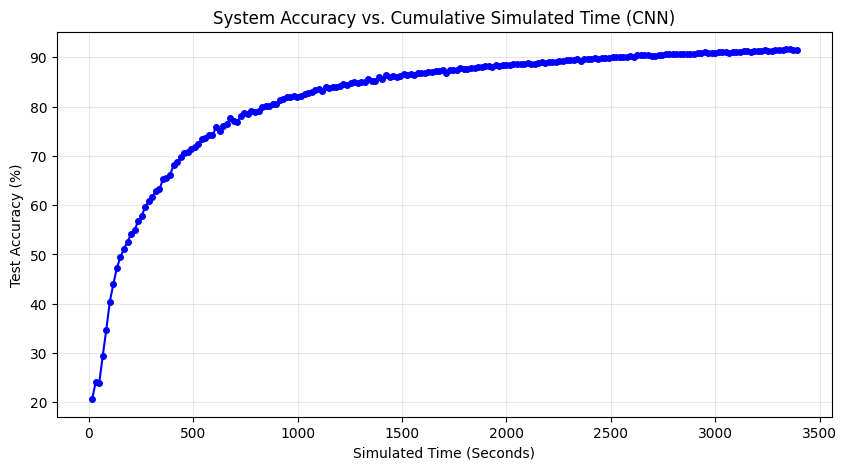

In [40]:
run_full_wireless_fl(task='CNN', rounds=200)


--- Starting SVM Wireless Federated Learning ---
Round 01 | Test Acc: 68.10% | Round Time: 0.01s | Total Time: 0.01s
Round 02 | Test Acc: 70.30% | Round Time: 0.01s | Total Time: 0.02s
Round 03 | Test Acc: 71.75% | Round Time: 0.01s | Total Time: 0.03s
Round 04 | Test Acc: 72.75% | Round Time: 0.01s | Total Time: 0.04s
Round 05 | Test Acc: 73.90% | Round Time: 0.01s | Total Time: 0.05s
Round 06 | Test Acc: 74.70% | Round Time: 0.01s | Total Time: 0.06s
Round 07 | Test Acc: 74.90% | Round Time: 0.01s | Total Time: 0.07s
Round 08 | Test Acc: 75.65% | Round Time: 0.01s | Total Time: 0.08s
Round 09 | Test Acc: 76.20% | Round Time: 0.01s | Total Time: 0.09s
Round 10 | Test Acc: 76.75% | Round Time: 0.01s | Total Time: 0.10s


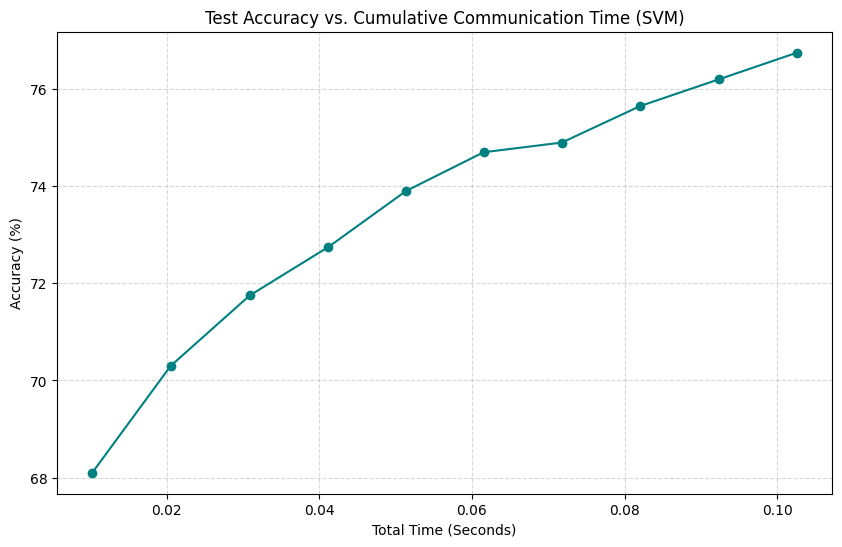


--- Starting CNN Wireless Federated Learning ---
Round 01 | Test Acc: 21.86% | Round Time: 1.96s | Total Time: 1.96s
Round 02 | Test Acc: 24.90% | Round Time: 1.95s | Total Time: 3.90s
Round 03 | Test Acc: 24.83% | Round Time: 1.94s | Total Time: 5.85s
Round 04 | Test Acc: 27.10% | Round Time: 1.95s | Total Time: 7.79s
Round 05 | Test Acc: 31.14% | Round Time: 1.95s | Total Time: 9.74s
Round 06 | Test Acc: 36.27% | Round Time: 1.96s | Total Time: 11.71s
Round 07 | Test Acc: 38.67% | Round Time: 1.96s | Total Time: 13.66s
Round 08 | Test Acc: 41.02% | Round Time: 1.95s | Total Time: 15.61s
Round 09 | Test Acc: 44.51% | Round Time: 1.96s | Total Time: 17.57s
Round 10 | Test Acc: 46.24% | Round Time: 1.88s | Total Time: 19.45s


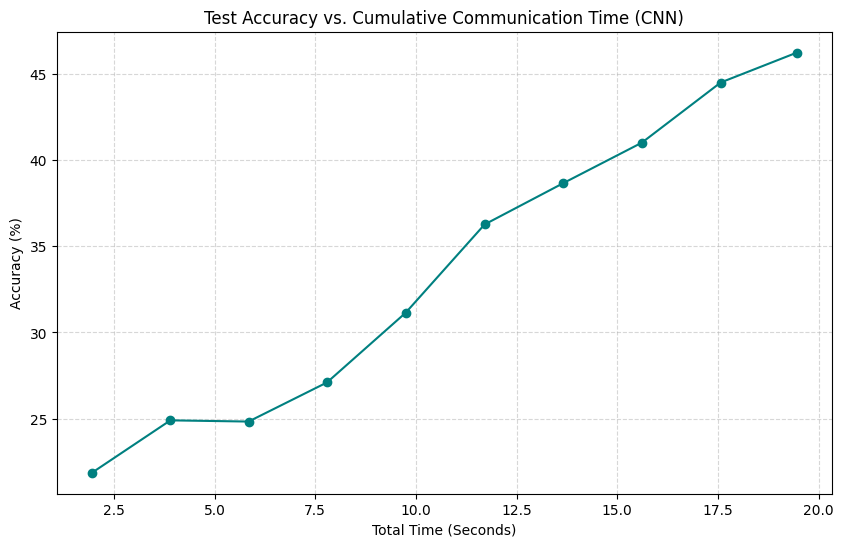

In [30]:
if __name__ == "__main__":
    run_full_wireless_fl(task='SVM', rounds=10)
    run_full_wireless_fl(task='CNN', rounds=10)